In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))


# 1. 기존 프로그램 방식
- 회귀분석(linear regression) 설명 사이트 : https://gbhat.com/machine_learning/linear_regression.html
- 오차함수 : MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE의 단점이 어느정도 해소. 이상치에 덜 민감), MAE(mean absolute erro error ; 절대값평균)
- 
https://jysden.medium.com/%EC%96%B8%EC%A0%9C-mse-mae-rmse%EB%A5%BC-%EC%82%AC%EC%9A%A9%ED%95%98%EB%8A%94%EA%B0%80-c473bd831c62
![image](https://miro.medium.com/v2/resize:fit:720/format:webp/1*XRXgMqrr5rq-V1rW7SkrtA.png)
- 경사하강법 설명 (https://www.mql5.com/ko/articles/11200)

In [2]:
# 섭씨 온도를 화씨 온도로 출력
# 기존 방식은 명확한 식을 통해 출력값을 만들어 냄
def celsius_to_faherenheit(c):
    return c*1.8+32

In [3]:
input_c = int(input('섭씨온도 : '))
print('화씨온도는', celsius_to_faherenheit(input_c))

섭씨온도 : 28
화씨온도는 82.4


# 2. 머신러닝 프로그래밍 방식
```
1. 데이터 확보 및 생성
2. 데이터 전처리 : 
    스케일 조정
    훈련데이터(학습데이터셋), 검증데이터셋, 시험데이터셋으로 분할
3. 모델구성
4. 모델 학습 과정 설정
5. 모델 학습시키기
6. 모델평가(시험데이터셋으로)
    <모델 저장>
7. 모델 사용(입력값이 주어지면 예측값 받기)

```

## 2.1 노이즈가 없는 데이터로 실습

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# 1. 데이터 생성
data_C = np.arange(100) # 0~99
data_C  # 독립변수(입력변수)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [8]:
data_F = celsius_to_faherenheit(data_C) 
data_F  # 종속변수(타겟변수, 출력변수)

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [9]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해 스케일 조정
scaled_data_C = data_C / 100.0
scaled_data_F = data_F / 100.0
print('학습시 독립변수 :', scaled_data_C)
print('학습시 종속변수 :', scaled_data_F)

학습시 독립변수 : [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
학습시 종속변수 : [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688 1

In [ ]:
import tensorflow as tf
print(tf.__version__)

In [11]:
# 3. 모델 구성
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense, Input # 입력값과 출력값으로 레이어층 지정

model = Sequential() # 빈모델 생성
# model.add(Input(shape=(1,) ))  # 입력 레이어 설정
# model.add(Dense(1))  # 출력 레이어

model.add(Dense(units=1, # 타겟(종속) 변수의 갯수
                input_shape = (1,))) # 입력(독립) 변수의 shape  

In [14]:
# 4. 모델 학습 과정 설정
model.compile(loss='mse',  # 오차(loss) 함수를 mse로 계산하겠다 - 모델학습중 오차를 최소화하기 위해 사용
             optimizer='rmsprop', # 옵티마이저 : 오차를 줄이는 최적화 방식을 'rmsprop'로 설정 / 
                                  # 옵티마이저 오솔길 검색하면 그 방식들이 여러개가 있음
             metrics=['mae'], # 평가 지표를 'mae'로 넣겠다
             )
# mse : 오차 제곱의 평균
# mae : 오차 절대값의 평균(이상치 영향이 감소)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


### 옵티마이저 오솔길
- 최근에는 Adam을 많이 사용하며, Nadam이 가장 최근 버전이라고 할 수 있다
<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2Fm6NoZ%2FbtsEHFRrBMP%2F9hQsj8P8FlGMkdW0Vg0VlK%2Fimg.png" 
     width="700" style="float: left;">

In [18]:
# 학습전 모델 예측
model.predict(np.array([[0],
                      [0.01]])) # 섭씨 온도 0, 섭씨온도 1도는 화씨온도 몇도?

1/1 [==============================] - 0s 284ms/step


array([[ 0.      ],
       [-0.012407]], dtype=float32)

In [19]:
model.save('model/before_learning.h5')

In [20]:
# 5. 모델 학습시키기 - 1번만 실행
hist = model.fit(scaled_data_C, # 입력변수(훈련데이터)
                 scaled_data_F, # 타겟변수(훈련데이터)
                 epochs=1000,  # 학습횟수
                 verbose=2  # 학습시 출력여부(0:학습내용출력, 1:학습내용 일부 출력, 2:학습내용 정확히 출력)
                )

Epoch 1/1000
4/4 - 0s - loss: 4.0831 - mae: 1.8206 - 330ms/epoch - 83ms/step
Epoch 2/1000
4/4 - 0s - loss: 4.0388 - mae: 1.8092 - 8ms/epoch - 2ms/step
Epoch 3/1000
4/4 - 0s - loss: 4.0066 - mae: 1.8011 - 8ms/epoch - 2ms/step
Epoch 4/1000
4/4 - 0s - loss: 3.9790 - mae: 1.7942 - 8ms/epoch - 2ms/step
Epoch 5/1000
4/4 - 0s - loss: 3.9519 - mae: 1.7873 - 8ms/epoch - 2ms/step
Epoch 6/1000
4/4 - 0s - loss: 3.9282 - mae: 1.7813 - 8ms/epoch - 2ms/step
Epoch 7/1000
4/4 - 0s - loss: 3.9043 - mae: 1.7750 - 8ms/epoch - 2ms/step
Epoch 8/1000
4/4 - 0s - loss: 3.8816 - mae: 1.7691 - 7ms/epoch - 2ms/step
Epoch 9/1000
4/4 - 0s - loss: 3.8593 - mae: 1.7634 - 8ms/epoch - 2ms/step
Epoch 10/1000
4/4 - 0s - loss: 3.8339 - mae: 1.7568 - 7ms/epoch - 2ms/step
Epoch 11/1000
4/4 - 0s - loss: 3.8106 - mae: 1.7507 - 8ms/epoch - 2ms/step
Epoch 12/1000
4/4 - 0s - loss: 3.7872 - mae: 1.7446 - 8ms/epoch - 2ms/step
Epoch 13/1000
4/4 - 0s - loss: 3.7641 - mae: 1.7386 - 7ms/epoch - 2ms/step
Epoch 14/1000
4/4 - 0s - loss: 

4/4 - 0s - loss: 1.9476 - mae: 1.1813 - 9ms/epoch - 2ms/step
Epoch 111/1000
4/4 - 0s - loss: 1.9328 - mae: 1.1760 - 6ms/epoch - 2ms/step
Epoch 112/1000
4/4 - 0s - loss: 1.9168 - mae: 1.1702 - 9ms/epoch - 2ms/step
Epoch 113/1000
4/4 - 0s - loss: 1.9020 - mae: 1.1652 - 6ms/epoch - 2ms/step
Epoch 114/1000
4/4 - 0s - loss: 1.8858 - mae: 1.1592 - 7ms/epoch - 2ms/step
Epoch 115/1000
4/4 - 0s - loss: 1.8700 - mae: 1.1537 - 7ms/epoch - 2ms/step
Epoch 116/1000
4/4 - 0s - loss: 1.8554 - mae: 1.1485 - 6ms/epoch - 2ms/step
Epoch 117/1000
4/4 - 0s - loss: 1.8409 - mae: 1.1433 - 11ms/epoch - 3ms/step
Epoch 118/1000
4/4 - 0s - loss: 1.8269 - mae: 1.1381 - 6ms/epoch - 2ms/step
Epoch 119/1000
4/4 - 0s - loss: 1.8140 - mae: 1.1335 - 6ms/epoch - 2ms/step
Epoch 120/1000
4/4 - 0s - loss: 1.7993 - mae: 1.1283 - 8ms/epoch - 2ms/step
Epoch 121/1000
4/4 - 0s - loss: 1.7826 - mae: 1.1223 - 6ms/epoch - 2ms/step
Epoch 122/1000
4/4 - 0s - loss: 1.7675 - mae: 1.1168 - 8ms/epoch - 2ms/step
Epoch 123/1000
4/4 - 0s - 

Epoch 218/1000
4/4 - 0s - loss: 0.7122 - mae: 0.6903 - 6ms/epoch - 2ms/step
Epoch 219/1000
4/4 - 0s - loss: 0.7039 - mae: 0.6865 - 8ms/epoch - 2ms/step
Epoch 220/1000
4/4 - 0s - loss: 0.6977 - mae: 0.6836 - 7ms/epoch - 2ms/step
Epoch 221/1000
4/4 - 0s - loss: 0.6907 - mae: 0.6803 - 6ms/epoch - 2ms/step
Epoch 222/1000
4/4 - 0s - loss: 0.6831 - mae: 0.6767 - 8ms/epoch - 2ms/step
Epoch 223/1000
4/4 - 0s - loss: 0.6759 - mae: 0.6734 - 6ms/epoch - 2ms/step
Epoch 224/1000
4/4 - 0s - loss: 0.6689 - mae: 0.6700 - 7ms/epoch - 2ms/step
Epoch 225/1000
4/4 - 0s - loss: 0.6601 - mae: 0.6658 - 6ms/epoch - 2ms/step
Epoch 226/1000
4/4 - 0s - loss: 0.6538 - mae: 0.6628 - 8ms/epoch - 2ms/step
Epoch 227/1000
4/4 - 0s - loss: 0.6472 - mae: 0.6597 - 7ms/epoch - 2ms/step
Epoch 228/1000
4/4 - 0s - loss: 0.6414 - mae: 0.6569 - 7ms/epoch - 2ms/step
Epoch 229/1000
4/4 - 0s - loss: 0.6345 - mae: 0.6536 - 7ms/epoch - 2ms/step
Epoch 230/1000
4/4 - 0s - loss: 0.6279 - mae: 0.6505 - 8ms/epoch - 2ms/step
Epoch 231/10

Epoch 326/1000
4/4 - 0s - loss: 0.2724 - mae: 0.4516 - 6ms/epoch - 1ms/step
Epoch 327/1000
4/4 - 0s - loss: 0.2711 - mae: 0.4505 - 7ms/epoch - 2ms/step
Epoch 328/1000
4/4 - 0s - loss: 0.2695 - mae: 0.4494 - 6ms/epoch - 2ms/step
Epoch 329/1000
4/4 - 0s - loss: 0.2683 - mae: 0.4484 - 7ms/epoch - 2ms/step
Epoch 330/1000
4/4 - 0s - loss: 0.2668 - mae: 0.4471 - 6ms/epoch - 1ms/step
Epoch 331/1000
4/4 - 0s - loss: 0.2661 - mae: 0.4465 - 8ms/epoch - 2ms/step
Epoch 332/1000
4/4 - 0s - loss: 0.2653 - mae: 0.4459 - 6ms/epoch - 2ms/step
Epoch 333/1000
4/4 - 0s - loss: 0.2645 - mae: 0.4453 - 7ms/epoch - 2ms/step
Epoch 334/1000
4/4 - 0s - loss: 0.2634 - mae: 0.4444 - 6ms/epoch - 2ms/step
Epoch 335/1000
4/4 - 0s - loss: 0.2621 - mae: 0.4433 - 8ms/epoch - 2ms/step
Epoch 336/1000
4/4 - 0s - loss: 0.2608 - mae: 0.4423 - 6ms/epoch - 1ms/step
Epoch 337/1000
4/4 - 0s - loss: 0.2595 - mae: 0.4412 - 6ms/epoch - 2ms/step
Epoch 338/1000
4/4 - 0s - loss: 0.2586 - mae: 0.4404 - 6ms/epoch - 2ms/step
Epoch 339/10

Epoch 434/1000
4/4 - 0s - loss: 0.1758 - mae: 0.3622 - 7ms/epoch - 2ms/step
Epoch 435/1000
4/4 - 0s - loss: 0.1749 - mae: 0.3613 - 5ms/epoch - 1ms/step
Epoch 436/1000
4/4 - 0s - loss: 0.1742 - mae: 0.3605 - 8ms/epoch - 2ms/step
Epoch 437/1000
4/4 - 0s - loss: 0.1733 - mae: 0.3596 - 6ms/epoch - 1ms/step
Epoch 438/1000
4/4 - 0s - loss: 0.1725 - mae: 0.3587 - 7ms/epoch - 2ms/step
Epoch 439/1000
4/4 - 0s - loss: 0.1715 - mae: 0.3577 - 6ms/epoch - 1ms/step
Epoch 440/1000
4/4 - 0s - loss: 0.1709 - mae: 0.3571 - 7ms/epoch - 2ms/step
Epoch 441/1000
4/4 - 0s - loss: 0.1700 - mae: 0.3561 - 6ms/epoch - 2ms/step
Epoch 442/1000
4/4 - 0s - loss: 0.1692 - mae: 0.3552 - 7ms/epoch - 2ms/step
Epoch 443/1000
4/4 - 0s - loss: 0.1685 - mae: 0.3544 - 6ms/epoch - 2ms/step
Epoch 444/1000
4/4 - 0s - loss: 0.1677 - mae: 0.3536 - 6ms/epoch - 1ms/step
Epoch 445/1000
4/4 - 0s - loss: 0.1670 - mae: 0.3528 - 8ms/epoch - 2ms/step
Epoch 446/1000
4/4 - 0s - loss: 0.1663 - mae: 0.3520 - 6ms/epoch - 2ms/step
Epoch 447/10

Epoch 542/1000
4/4 - 0s - loss: 0.1011 - mae: 0.2742 - 7ms/epoch - 2ms/step
Epoch 543/1000
4/4 - 0s - loss: 0.1004 - mae: 0.2733 - 6ms/epoch - 2ms/step
Epoch 544/1000
4/4 - 0s - loss: 0.0998 - mae: 0.2725 - 8ms/epoch - 2ms/step
Epoch 545/1000
4/4 - 0s - loss: 0.0992 - mae: 0.2716 - 7ms/epoch - 2ms/step
Epoch 546/1000
4/4 - 0s - loss: 0.0985 - mae: 0.2707 - 7ms/epoch - 2ms/step
Epoch 547/1000
4/4 - 0s - loss: 0.0978 - mae: 0.2697 - 5ms/epoch - 1ms/step
Epoch 548/1000
4/4 - 0s - loss: 0.0972 - mae: 0.2690 - 8ms/epoch - 2ms/step
Epoch 549/1000
4/4 - 0s - loss: 0.0966 - mae: 0.2681 - 6ms/epoch - 2ms/step
Epoch 550/1000
4/4 - 0s - loss: 0.0960 - mae: 0.2673 - 6ms/epoch - 2ms/step
Epoch 551/1000
4/4 - 0s - loss: 0.0955 - mae: 0.2665 - 7ms/epoch - 2ms/step
Epoch 552/1000
4/4 - 0s - loss: 0.0949 - mae: 0.2657 - 6ms/epoch - 2ms/step
Epoch 553/1000
4/4 - 0s - loss: 0.0944 - mae: 0.2650 - 7ms/epoch - 2ms/step
Epoch 554/1000
4/4 - 0s - loss: 0.0939 - mae: 0.2641 - 5ms/epoch - 1ms/step
Epoch 555/10

Epoch 650/1000
4/4 - 0s - loss: 0.0449 - mae: 0.1829 - 8ms/epoch - 2ms/step
Epoch 651/1000
4/4 - 0s - loss: 0.0445 - mae: 0.1821 - 6ms/epoch - 2ms/step
Epoch 652/1000
4/4 - 0s - loss: 0.0441 - mae: 0.1813 - 6ms/epoch - 1ms/step
Epoch 653/1000
4/4 - 0s - loss: 0.0437 - mae: 0.1804 - 6ms/epoch - 2ms/step
Epoch 654/1000
4/4 - 0s - loss: 0.0433 - mae: 0.1797 - 7ms/epoch - 2ms/step
Epoch 655/1000
4/4 - 0s - loss: 0.0430 - mae: 0.1791 - 7ms/epoch - 2ms/step
Epoch 656/1000
4/4 - 0s - loss: 0.0426 - mae: 0.1782 - 5ms/epoch - 1ms/step
Epoch 657/1000
4/4 - 0s - loss: 0.0423 - mae: 0.1773 - 6ms/epoch - 2ms/step
Epoch 658/1000
4/4 - 0s - loss: 0.0420 - mae: 0.1768 - 5ms/epoch - 1ms/step
Epoch 659/1000
4/4 - 0s - loss: 0.0416 - mae: 0.1761 - 7ms/epoch - 2ms/step
Epoch 660/1000
4/4 - 0s - loss: 0.0413 - mae: 0.1754 - 6ms/epoch - 1ms/step
Epoch 661/1000
4/4 - 0s - loss: 0.0409 - mae: 0.1746 - 7ms/epoch - 2ms/step
Epoch 662/1000
4/4 - 0s - loss: 0.0406 - mae: 0.1738 - 5ms/epoch - 1ms/step
Epoch 663/10

Epoch 758/1000
4/4 - 0s - loss: 0.0120 - mae: 0.0948 - 6ms/epoch - 1ms/step
Epoch 759/1000
4/4 - 0s - loss: 0.0118 - mae: 0.0939 - 7ms/epoch - 2ms/step
Epoch 760/1000
4/4 - 0s - loss: 0.0115 - mae: 0.0928 - 5ms/epoch - 1ms/step
Epoch 761/1000
4/4 - 0s - loss: 0.0113 - mae: 0.0919 - 8ms/epoch - 2ms/step
Epoch 762/1000
4/4 - 0s - loss: 0.0111 - mae: 0.0911 - 5ms/epoch - 1ms/step
Epoch 763/1000
4/4 - 0s - loss: 0.0109 - mae: 0.0903 - 8ms/epoch - 2ms/step
Epoch 764/1000
4/4 - 0s - loss: 0.0107 - mae: 0.0895 - 5ms/epoch - 1ms/step
Epoch 765/1000
4/4 - 0s - loss: 0.0105 - mae: 0.0886 - 7ms/epoch - 2ms/step
Epoch 766/1000
4/4 - 0s - loss: 0.0103 - mae: 0.0877 - 6ms/epoch - 2ms/step
Epoch 767/1000
4/4 - 0s - loss: 0.0101 - mae: 0.0868 - 6ms/epoch - 1ms/step
Epoch 768/1000
4/4 - 0s - loss: 0.0099 - mae: 0.0859 - 6ms/epoch - 2ms/step
Epoch 769/1000
4/4 - 0s - loss: 0.0096 - mae: 0.0849 - 6ms/epoch - 2ms/step
Epoch 770/1000
4/4 - 0s - loss: 0.0095 - mae: 0.0840 - 7ms/epoch - 2ms/step
Epoch 771/10

Epoch 865/1000
4/4 - 0s - loss: 8.4390e-05 - mae: 0.0079 - 6ms/epoch - 2ms/step
Epoch 866/1000
4/4 - 0s - loss: 7.3711e-05 - mae: 0.0074 - 7ms/epoch - 2ms/step
Epoch 867/1000
4/4 - 0s - loss: 5.9783e-05 - mae: 0.0067 - 6ms/epoch - 2ms/step
Epoch 868/1000
4/4 - 0s - loss: 4.9965e-05 - mae: 0.0061 - 7ms/epoch - 2ms/step
Epoch 869/1000
4/4 - 0s - loss: 4.0690e-05 - mae: 0.0055 - 6ms/epoch - 1ms/step
Epoch 870/1000
4/4 - 0s - loss: 3.3687e-05 - mae: 0.0050 - 8ms/epoch - 2ms/step
Epoch 871/1000
4/4 - 0s - loss: 2.4883e-05 - mae: 0.0043 - 5ms/epoch - 1ms/step
Epoch 872/1000
4/4 - 0s - loss: 2.0705e-05 - mae: 0.0040 - 8ms/epoch - 2ms/step
Epoch 873/1000
4/4 - 0s - loss: 1.4045e-05 - mae: 0.0032 - 5ms/epoch - 1ms/step
Epoch 874/1000
4/4 - 0s - loss: 1.2146e-05 - mae: 0.0029 - 9ms/epoch - 2ms/step
Epoch 875/1000
4/4 - 0s - loss: 7.5873e-06 - mae: 0.0024 - 5ms/epoch - 1ms/step
Epoch 876/1000
4/4 - 0s - loss: 5.3033e-06 - mae: 0.0020 - 7ms/epoch - 2ms/step
Epoch 877/1000
4/4 - 0s - loss: 3.1656e-

Epoch 964/1000
4/4 - 0s - loss: 8.3064e-07 - mae: 8.9117e-04 - 6ms/epoch - 2ms/step
Epoch 965/1000
4/4 - 0s - loss: 4.5463e-07 - mae: 6.6259e-04 - 6ms/epoch - 2ms/step
Epoch 966/1000
4/4 - 0s - loss: 3.8390e-07 - mae: 6.0555e-04 - 6ms/epoch - 2ms/step
Epoch 967/1000
4/4 - 0s - loss: 7.1052e-07 - mae: 8.2799e-04 - 6ms/epoch - 1ms/step
Epoch 968/1000
4/4 - 0s - loss: 5.1788e-07 - mae: 7.0709e-04 - 7ms/epoch - 2ms/step
Epoch 969/1000
4/4 - 0s - loss: 9.1173e-07 - mae: 9.2955e-04 - 6ms/epoch - 2ms/step
Epoch 970/1000
4/4 - 0s - loss: 3.8348e-07 - mae: 6.0252e-04 - 7ms/epoch - 2ms/step
Epoch 971/1000
4/4 - 0s - loss: 3.7254e-07 - mae: 5.9445e-04 - 5ms/epoch - 1ms/step
Epoch 972/1000
4/4 - 0s - loss: 3.7253e-07 - mae: 5.9140e-04 - 8ms/epoch - 2ms/step
Epoch 973/1000
4/4 - 0s - loss: 9.3349e-07 - mae: 9.5086e-04 - 7ms/epoch - 2ms/step
Epoch 974/1000
4/4 - 0s - loss: 4.0312e-07 - mae: 6.2125e-04 - 8ms/epoch - 2ms/step
Epoch 975/1000
4/4 - 0s - loss: 4.3394e-07 - mae: 6.4377e-04 - 5ms/epoch - 1

In [24]:
# 6. 모델 평가(그래프를 통해 loss와 metrics값의 추이 확인, 예측정확도 평가함수)
print(hist.history.keys())
print(hist.history['loss'][:5])
print(hist.history['mae'][:5])

dict_keys(['loss', 'mae'])
[4.083069324493408, 4.038815498352051, 4.006571292877197, 3.979036808013916, 3.951944351196289]
[1.8205657005310059, 1.8092124462127686, 1.801082968711853, 1.7942047119140625, 1.787287712097168]


Text(0.5, 1.0, 'Model loss & MAE over epochs')

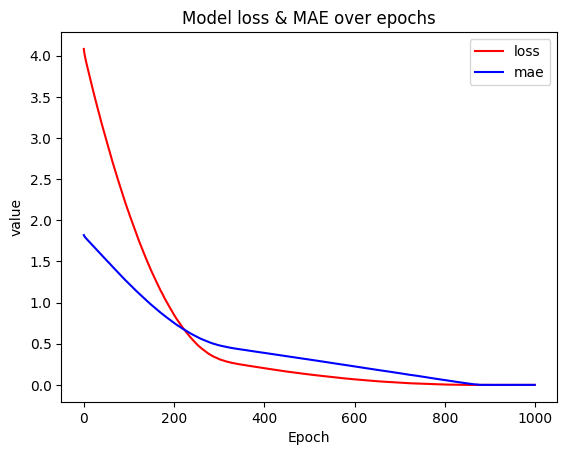

In [28]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend() # 범례 label추가
plt.xlabel('Epoch')
plt.ylabel('value')
plt.title('Model loss & MAE over epochs')

In [29]:
# 7. 모델 저장 및 사용
# 학습 후 예측
model.predict(np.array([[0],
                      [0.01]]))

1/1 [==============================] - 0s 28ms/step


array([[0.3196006 ],
       [0.33759582]], dtype=float32)

In [30]:
model.save('model/after_learning.h5')

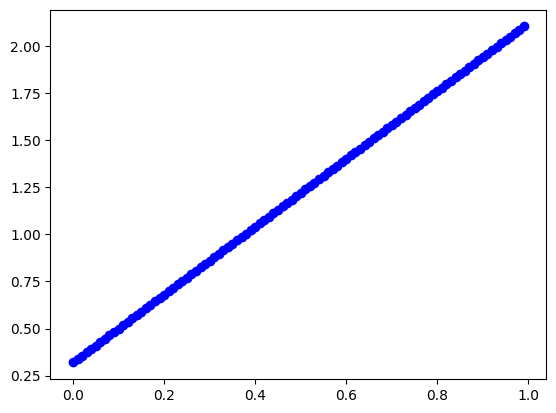

In [33]:
# 실제값
plt.scatter(x=scaled_data_C,
           y=scaled_data_F, 
            c='b')
plt.show()

In [35]:
# 예측값
y_hat = model.predict([scaled_data_C])
for h, y in zip(y_hat, scaled_data_F):
    print('예측값 : {}, 실제값:{}, 오차:{}'.format(h, 
                                           y, 
                                           h[0]-y))
    

4/4 [==============================] - 0s 1ms/step
예측값 : [0.3196006], 실제값:0.32, 오차:-0.0003993880748748846
예측값 : [0.33759582], 실제값:0.33799999999999997, 오차:-0.00040417957305904917
예측값 : [0.35559106], 실제값:0.35600000000000004, 오차:-0.0004089412689209371
예측값 : [0.37358627], 실제값:0.374, 오차:-0.00041373276710510165
예측값 : [0.39158148], 실제값:0.392, 오차:-0.00041852426528932174
예측값 : [0.4095767], 실제값:0.41, 오차:-0.0004232859611510986
예측값 : [0.42757192], 실제값:0.428, 오차:-0.0004280774593353187
예측값 : [0.44556713], 실제값:0.446, 오차:-0.0004328689575195388
예측값 : [0.46356237], 실제값:0.46399999999999997, 오차:-0.0004376306533813157
예측값 : [0.48155758], 실제값:0.48200000000000004, 오차:-0.0004424221515655913
예측값 : [0.4995528], 실제값:0.5, 오차:-0.00044721364974975586
예측값 : [0.517548], 실제값:0.518, 오차:-0.00045197534561158825
예측값 : [0.5355432], 실제값:0.536, 오차:-0.00045679664611819604
예측값 : [0.55353844], 실제값:0.554, 오차:-0.00046155834198002843
예측값 : [0.5715337], 실제값:0.5720000000000001, 오차:-0.0004663200378418608
예측값 : [0.5895289], 실제값:0.59, 

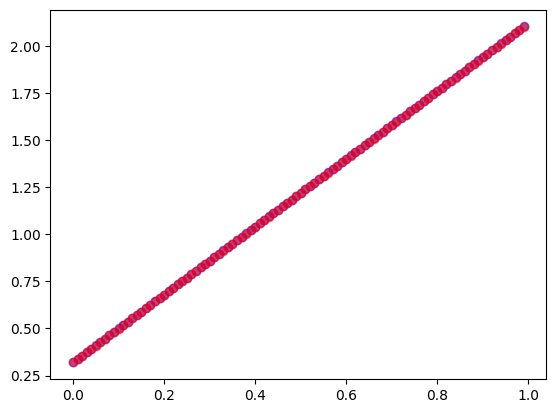

In [37]:
plt.scatter(x=scaled_data_C, y=scaled_data_F,
           c='b', alpha=0.5)  # 투명한 점그래프

plt.scatter(x=scaled_data_C, y=y_hat,
           c='r', alpha=0.5)

## 2.2 노이즈가 있는 데이터로 실습

In [40]:
# 노이즈 부여를 위한 랜덤지수 생성 및 부여
np.random.seed(7)
noise = np.random.normal(0,scale= 0.1, size=100) # 평균 0, 표준편차 0.1의 100개 데이터
noised_scaled_data_F = scaled_data_F + noise  # 노이즈 값 추가

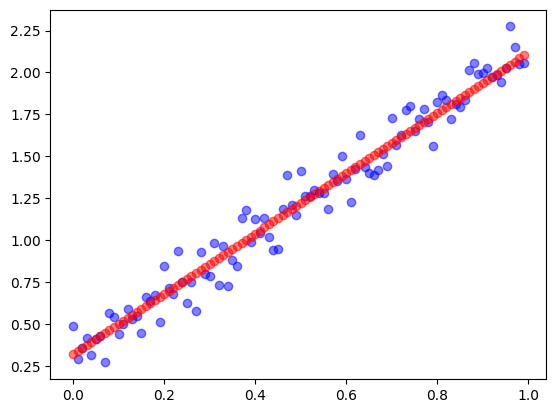

In [41]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F,
           c='b', alpha=0.5)  # 투명한 점그래프

plt.scatter(x=scaled_data_C, y=y_hat,
           c='r', alpha=0.5)

In [43]:
# 모델구성
model2 = Sequential()
model2.add(Dense(1, input_shape=(1,)))
# 4. 학습과정 설정
model2.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
model2.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [44]:
# 5. 모델 학습
hist2 = model2.fit(scaled_data_C, noised_scaled_data_F,
                  epochs=1000, verbose = 1)

Epoch 1/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.5979 - mae: 1.1564
Epoch 2/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.5713 - mae: 1.1461
Epoch 3/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.5498 - mae: 1.1375
Epoch 4/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.5317 - mae: 1.1299
Epoch 5/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.5156 - mae: 1.1233
Epoch 6/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.5023 - mae: 1.1179
Epoch 7/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.4864 - mae: 1.1114
Epoch 8/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.4709 - mae: 1.1049
Epoch 9/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.4579 - mae: 1.0995
Epoch 10/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.4438 - mae: 1.0935
Epoch 11/1000
4/4 [==============================] - 0s 2ms/step - lo

4/4 [==============================] - 0s 2ms/step - loss: 0.1309 - mae: 0.3047
Epoch 175/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1289 - mae: 0.3023
Epoch 176/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1265 - mae: 0.2999
Epoch 177/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1238 - mae: 0.2969
Epoch 178/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1222 - mae: 0.2951
Epoch 179/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1208 - mae: 0.2935
Epoch 180/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.1187 - mae: 0.2913
Epoch 181/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1169 - mae: 0.2893
Epoch 182/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1148 - mae: 0.2868
Epoch 183/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1127 - mae: 0.2844
Epoch 184/1000
4/4 [==============================] - 0s 1ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0327 - mae: 0.1501
Epoch 347/1000
4/4 [==============================] - 0s 7ms/step - loss: 0.0324 - mae: 0.1494
Epoch 348/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0322 - mae: 0.1487
Epoch 349/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0320 - mae: 0.1483
Epoch 350/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0317 - mae: 0.1477
Epoch 351/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0315 - mae: 0.1471
Epoch 352/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0312 - mae: 0.1465
Epoch 353/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0310 - mae: 0.1461
Epoch 354/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0308 - mae: 0.1454
Epoch 355/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0305 - mae: 0.1450
Epoch 356/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 3ms/step - loss: 0.0114 - mae: 0.0833
Epoch 519/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0113 - mae: 0.0830
Epoch 520/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0113 - mae: 0.0829
Epoch 521/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0112 - mae: 0.0828
Epoch 522/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0112 - mae: 0.0826
Epoch 523/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0112 - mae: 0.0826
Epoch 524/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0112 - mae: 0.0826
Epoch 525/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0112 - mae: 0.0824
Epoch 526/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0112 - mae: 0.0823
Epoch 527/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0111 - mae: 0.0823
Epoch 528/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0804
Epoch 691/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0803
Epoch 692/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0802
Epoch 693/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0802
Epoch 694/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0804
Epoch 695/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0806
Epoch 696/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 697/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 698/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 699/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0805
Epoch 700/1000
4/4 [==============================] - 0s 4ms/step

4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0805
Epoch 863/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0803
Epoch 864/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0803
Epoch 865/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0803
Epoch 866/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0805
Epoch 867/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0805
Epoch 868/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0807
Epoch 869/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 870/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 871/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 872/1000
4/4 [==============================] - 0s 2ms/step

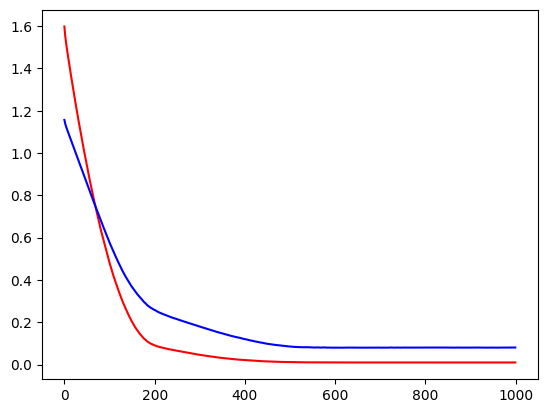

In [46]:
# 6. 모델 평가
plt.plot(hist2.history['loss'], c='r')
plt.plot(hist2.history['mae'], c='b')

In [47]:
model2.save('model/noise_after_learning.h5')

In [48]:
# 예측값
y_hat = model2.predict([scaled_data_C])

4/4 [==============================] - 0s 1ms/step


In [49]:
for h, y in zip(y_hat, noised_scaled_data_F):
    print("실제값:{}, 예측값:{}, 오차:{}".format(y,
                                        h,
                                        h[0]-y))

실제값:0.48905257038003563, 예측값:[0.3058711], 오차:-0.18318147114640831
실제값:0.2914062629459167, 예측값:[0.32425278], 오차:0.03284652130625004
실제값:0.3592820163678585, 예측값:[0.34263444], 오차:-0.016647576899474714
실제값:0.4147516282996508, 예측값:[0.3610161], 오차:-0.05373553361504996
실제값:0.31310769713742614, 예측값:[0.37939778], 오차:0.06629008256571411
실제값:0.4102065572905948, 예측값:[0.39777946], 오차:-0.01242709256891511
실제값:0.42791096141420687, 예측값:[0.41616112], 오차:-0.011749841476310141
실제값:0.2705275693654579, 예측값:[0.43454278], 오차:0.16401520578865586
실제값:0.5657658005663493, 예측값:[0.45292446], 오차:-0.11284134039369609
실제값:0.542049851591955, 예측값:[0.47130615], 오차:-0.07074370640076233
실제값:0.43745710260332404, 예측값:[0.4896878], 오차:0.052230697804085624
실제값:0.5008451738804279, 예측값:[0.50806946], 오차:0.007224281743198779
실제값:0.5865299374196752, 예측값:[0.5264511], 오차:-0.060078826579831435
실제값:0.5278643584808353, 예측값:[0.5448328], 오차:0.016968467179870217
실제값:0.5477250921327455, 예측값:[0.5632145], 오차:0.015489388744177157
실제값:0.4446758

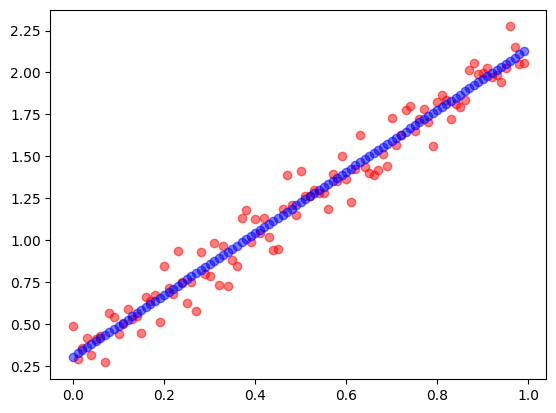

In [50]:
plt.scatter(x=scaled_data_C,
           y=noised_scaled_data_F,
           c='r', alpha=0.5)
plt.scatter(x=scaled_data_C,
           y=y_hat,
           c='b', alpha=0.5)